In [1]:
import sys
import os
import glob
from scipy import stats

import dabest

import numpy as np
import scipy as sp
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:01<00:00, 10.39it/s]

Numba compilation complete!


In [2]:
specifiedpath = "D:"


filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Cell stainings\\MB247\\"
sum_csv = "ACR eOPN3 SUM Posterior vs Anterior.csv"

df_sum= pd.read_csv(specifiedpath + filedir + sum_csv)

df  = df_sum.replace({"ACR1": "GtACR1", "eOPN3": "OPN3"}, regex=True)
df1 = df.iloc[0:36,0:5]
df1["Genotype_Position"] = df["Genotype"] + " " + df["Position"]

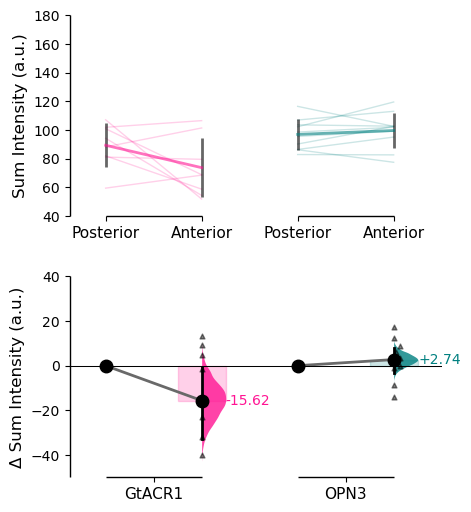

In [4]:
paired_data = dabest.load(data = df1, 
                          idx = (("GtACR1 Posterior", "GtACR1 Anterior"), ("OPN3 Posterior", "OPN3 Anterior")), 
                          paired='baseline', id_col="ID",
                          x = "Genotype_Position", y="Value")

palette = {'GtACR1 Posterior':'deeppink','GtACR1 Anterior':'deeppink', 
           'OPN3 Posterior' : 'teal', 'OPN3 Anterior' : 'teal'}
genoListNL = ['GtACR1','OPN3']

compare = paired_data.mean_diff.plot(fontsize_rawxlabel=9, fontsize_contrastxlabel=9, 
                                    contrast_ylim=(-50, 40), raw_ylim=(40, 180), 
                                    custom_palette=palette, raw_desat=1, contrast_desat=1)
ax_raw = compare.axes[0]

n_gtacr1 = len(df1[df1['Genotype'] == 'GtACR1']['ID'].unique())
n_asopn3 = len(df1[df1['Genotype'] == 'OPN3']['ID'].unique())

for line in ax_raw.lines:
    xdata = line.get_xdata()
    if len(xdata) == 2:
        if xdata[0] < 1.5:  
            line.set_color('deeppink')
        else:  # OPN3 group 
            line.set_color('teal')

compare.axes[0].set_xticklabels(["Posterior", "Anterior", "Posterior", "Anterior"], fontsize=11)
compare.axes[0].set_ylabel('Sum Intensity (a.u.)')
compare.axes[1].set_ylabel('Δ Sum Intensity (a.u.)')

compare.axes[1].spines['bottom'].set_visible(False)
compare.axes[1].set_xticks([0.5, 2.5])
compare.axes[1].set_xticklabels(genoListNL, fontsize=11)

plt.show()
